# Federated Learning Timing and Accuracy Analysis
## Focus: Bottleneck di comunicazione e accuratezza

Notebook strutturato in due parti:
1. Flower Bagging vs Flower Cyclic
2. Flower Bagging vs Flower Cyclic vs NVIDIA FLARE

Obiettivo principale: capire dove si perde tempo (setup, avvio client, training) e come cambia l'accuratezza.

In [ ]:
# importa le librerie necessarie
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # serve per migliorare l'estetica dei grafici

plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("Set2")
%matplotlib inline 
# per visualizzare i grafici direttamente nel notebook

ROOT = Path("..").resolve()
BENCHMARKS_DIR = ROOT / "benchmarks"
RESULTS_DIR = ROOT / "results"
PLOTS_DIR = RESULTS_DIR / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True) # crea la cartella per i grafici se non esiste

# Se la metrica di accuratezza non c'è, usa questo fallback.
manual_mae = {
    "flower_bagging": 12.23,
    "flower_cyclic": 11.38,
    "nvidia_flare": np.nan,
}

print(f"Root: {ROOT}")
print(f"Benchmarks: {BENCHMARKS_DIR}")
print(f"Results: {RESULTS_DIR}")

Root: /Users/annamettifogo/Desktop/polimi/necstlab/progetto_LS2/fl_benchmark
Benchmarks: /Users/annamettifogo/Desktop/polimi/necstlab/progetto_LS2/fl_benchmark/benchmarks
Results: /Users/annamettifogo/Desktop/polimi/necstlab/progetto_LS2/fl_benchmark/results


## Parte A - Flower Bagging vs Flower Cyclic

Prima confrontiamo solo i due approcci Flower in termini di timing e accuratezza.

In [4]:
def load_json_if_exists(path: Path):
    if not path.exists():
        return None
    with open(path, "r") as f:
        return json.load(f)

bagging_timing = load_json_if_exists(BENCHMARKS_DIR / "flower_bagging" / "results" / "timing_metrics.json")
cyclic_timing = load_json_if_exists(BENCHMARKS_DIR / "flower_cyclic" / "results" / "timing_metrics.json")

records = []
for name, payload in [("flower_bagging", bagging_timing), ("flower_cyclic", cyclic_timing)]:
    if payload is None:
        continue
    total = float(payload.get("total_time", np.nan))
    fl_time = float(payload.get("fl_time", np.nan))
    rec = {
        "approach": name,
        "total_time_s": total,
        "fl_time_s": fl_time,
        "setup_plus_overhead_s": max(total - fl_time, 0.0) if pd.notna(total) and pd.notna(fl_time) else np.nan,
        "avg_round_time_s": float(payload.get("avg_round_time", np.nan)),
        "num_rounds": int(payload.get("num_rounds", np.nan)) if str(payload.get("num_rounds", "")).isdigit() else payload.get("num_rounds"),
    }
    records.append(rec)

df_bc = pd.DataFrame(records)

display(df_bc)
if df_bc.empty:
    print("Nessun timing trovato per Bagging/Cyclic.")

,approach,total_time_s,fl_time_s,setup_plus_overhead_s,avg_round_time_s,num_rounds
0,flower_bagging,26.316734,26.258841,0.057893,2.625884,10
1,flower_cyclic,19.621081,19.588958,0.032123,1.958896,10


### A1. Confronto tempi globali (Bagging vs Cyclic)

Confronto su tempo totale e tempo medio per round.

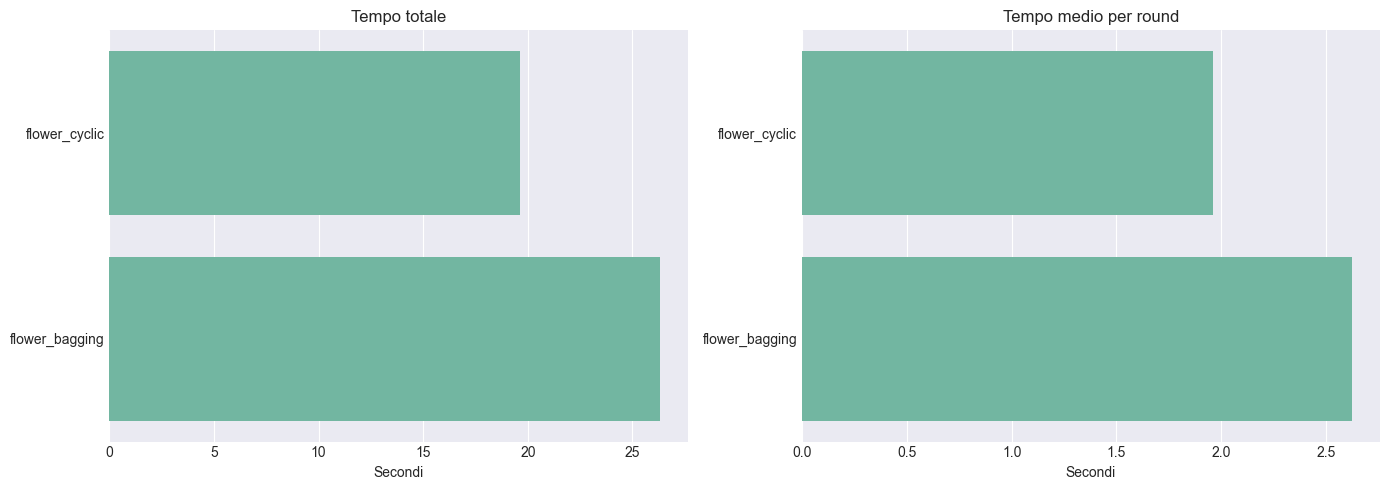

Piu' veloce: flower_cyclic (19.62s)
Riduzione tempo vs piu' lento: 25.4%


In [ ]:
if not df_bc.empty: # se ci sono dati, visualizza i grafici
    order = df_bc.sort_values("total_time_s") # ordina per tempo totale per avere sempre il più veloce in cima

    # grafici a barre per tempo totale e tempo medio per round
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # il primo grafico mostra il tempo totale
    sns.barplot(data=order, x="total_time_s", y="approach", ax=axes[0])
    axes[0].set_title("Tempo totale")
    axes[0].set_xlabel("Secondi")
    axes[0].set_ylabel("")

    # il secondo mostra il tempo medio per round
    sns.barplot(data=order, x="avg_round_time_s", y="approach", ax=axes[1])
    axes[1].set_title("Tempo medio per round")
    axes[1].set_xlabel("Secondi")
    axes[1].set_ylabel("")

    # aggiusta layout e mostra
    plt.tight_layout()
    plt.show()

    # confronto i due approcci se ci sono entrambi
    if len(order) == 2:
        fastest = order.iloc[0]
        slowest = order.iloc[1]
        pct = (slowest["total_time_s"] - fastest["total_time_s"]) / slowest["total_time_s"] * 100
        print(f"Più veloce: {fastest['approach']} ({fastest['total_time_s']:.2f}s)")
        print(f"Riduzione tempo vs più lento: {pct:.1f}%")

### A2. Breakdown fasi e bottleneck (Bagging vs Cyclic)

Con i file timing attuali, la scomposizione diretta disponibile e':
- fl_time_s: durata del ciclo federato
- setup_plus_overhead_s: differenza tra tempo totale e fl_time

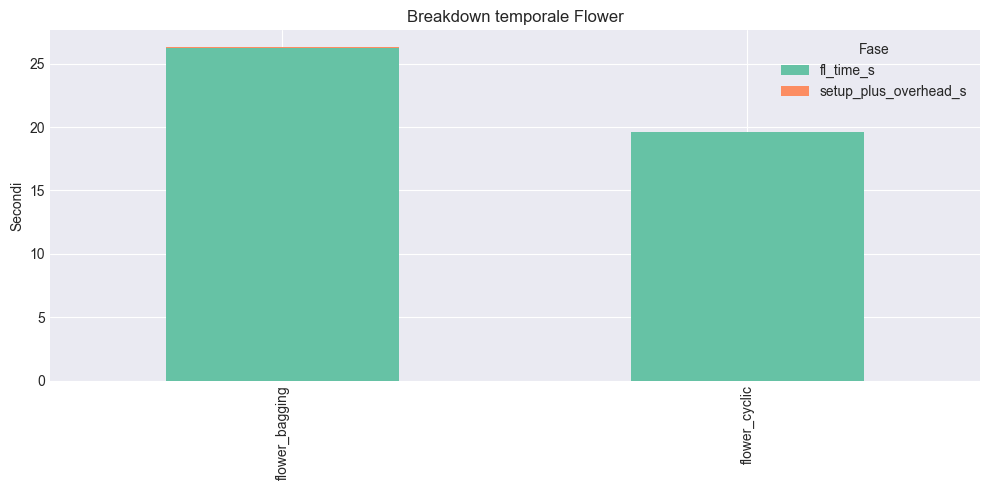

Quota percentuale per fase (%):


,fl_time_s,setup_plus_overhead_s
approach,,
flower_bagging,99.78,0.22
flower_cyclic,99.84,0.16


In [ ]:
if not df_bc.empty:
    # analisi del breakdown temporale
    phase_cols = ["fl_time_s", "setup_plus_overhead_s"] 
    phase_df = df_bc[["approach"] + phase_cols].set_index("approach") # approccio come indice per il grafico a barre

    # grafico a barre impilato per il breakdown temporale
    phase_df.plot(kind="bar", stacked=True, figsize=(10, 5))
    plt.title("Breakdown temporale Flower")
    plt.ylabel("Secondi")
    plt.xlabel("")
    plt.legend(title="Fase")
    plt.tight_layout()
    plt.show()

    # calcolo la quota percentuale di ogni fase sul totale
    share = phase_df.div(phase_df.sum(axis=1), axis=0) * 100
    print("Quota percentuale per fase (%):")
    display(share.round(2))

## Parte B - Flower vs NVIDIA FLARE

Ora estendiamo a 3 approcci e analizziamo piu' a fondo i tempi NVFLARE (configurazione client, avvio client, eventi all_reduce).

In [ ]:
nvflare_timing = load_json_if_exists(BENCHMARKS_DIR / "nvidia_flare" / "results" / "timing_metrics.json")
log_path = BENCHMARKS_DIR / "nvidia_flare" / "run_nvflare.log"

# se ci sono dati di timing per NVFlare, li aggiungo al dataframe con lo stesso formato degli altri
nvflare_row = None
if nvflare_timing is not None:
    total = float(nvflare_timing.get("total_time", np.nan))
    fl_time = float(nvflare_timing.get("fl_time", np.nan))
    nvflare_row = {
        "approach": "nvidia_flare",
        "total_time_s": total,
        "fl_time_s": fl_time,
        "setup_plus_overhead_s": max(total - fl_time, 0.0) if pd.notna(total) and pd.notna(fl_time) else np.nan,
        "avg_round_time_s": float(nvflare_timing.get("avg_round_time", np.nan)),
        "num_rounds": int(nvflare_timing.get("num_rounds", np.nan)) if str(nvflare_timing.get("num_rounds", "")).isdigit() else nvflare_timing.get("num_rounds"),
    }

# estraggo dal log di NVFlare eventuali metriche di fase come setup client, starting client, numero di allreduce, che non sono riportate nel JSON di timing ma possono essere utili per capire il breakdown temporale e il comportamento del sistema
phase_metrics = {
    "client_configuration_s": np.nan, # np.nan come default se non trovo la metrica
    "client_starting_s": np.nan,
    "allreduce_events": np.nan,
}

if log_path.exists():
    raw_log = log_path.read_text(errors="ignore") 
    clean_log = re.sub(r"\x1b\[[0-9;]*m", "", raw_log) 

    # cerco nel log le metriche di interesse usando regex, e conto il numero di eventi di allreduce
    m_cfg = re.search(r"client configuration took ([0-9]+\.?[0-9]*) seconds", clean_log)
    m_start = re.search(r"client starting took ([0-9]+\.?[0-9]*) seconds", clean_log)
    allreduce_count = len(re.findall(r"Request seq op='allreduce'", clean_log))

    # le aggiungo al dizionario phase_metrics
    if m_cfg:
        phase_metrics["client_configuration_s"] = float(m_cfg.group(1))
    if m_start:
        phase_metrics["client_starting_s"] = float(m_start.group(1))
    phase_metrics["allreduce_events"] = allreduce_count

# aggiungo alla riga nvflare
if nvflare_row is not None:
    nvflare_row.update(phase_metrics)

# creo nuovo dataframe 
df_three = df_bc.copy()
if nvflare_row is not None:
    df_three = pd.concat([df_three, pd.DataFrame([nvflare_row])], ignore_index=True)

display(df_three)


if not df_three.empty and "client_configuration_s" in df_three.columns:
    # stima della parte FL che non e' setup client
    df_three["fl_core_estimated_s"] = np.where(
        df_three["approach"].eq("nvidia_flare"),
        df_three["fl_time_s"] - df_three["client_configuration_s"].fillna(0) - df_three["client_starting_s"].fillna(0),
        np.nan,
    )
    display(df_three[[c for c in ["approach", "client_configuration_s", "client_starting_s", "fl_core_estimated_s", "allreduce_events"] if c in df_three.columns]])

,approach,total_time_s,fl_time_s,setup_plus_overhead_s,avg_round_time_s,num_rounds,client_configuration_s,client_starting_s,allreduce_events
0,flower_bagging,26.316734,26.258841,0.057893,2.625884,10,NaN,NaN,NaN
1,flower_cyclic,19.621081,19.588958,0.032123,1.958896,10,NaN,NaN,NaN
2,nvidia_flare,30.865464,30.864859,0.000605,3.086486,10,5.616521,2.28091,1089.0


,approach,client_configuration_s,client_starting_s,fl_core_estimated_s,allreduce_events
0,flower_bagging,NaN,NaN,NaN,NaN
1,flower_cyclic,NaN,NaN,NaN,NaN
2,nvidia_flare,5.616521,2.28091,22.967428,1089.0


### B1. Tempi globali e colli di bottiglia principali

Confronto a 3 approcci sui tempi globali e zoom sulle fasi NVFLARE.

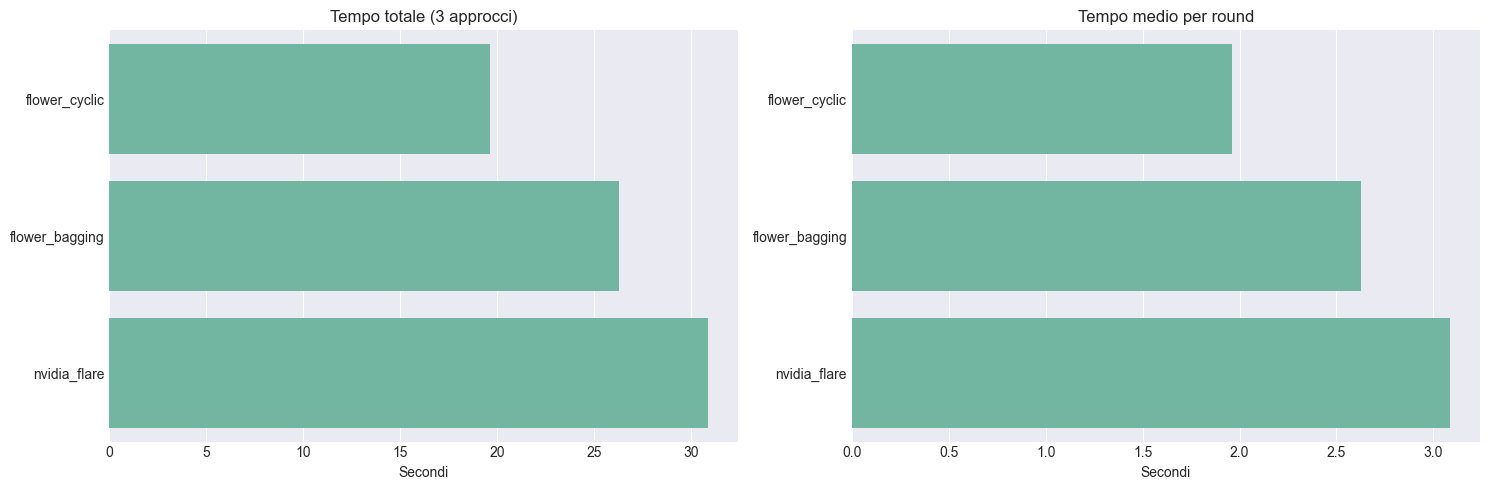

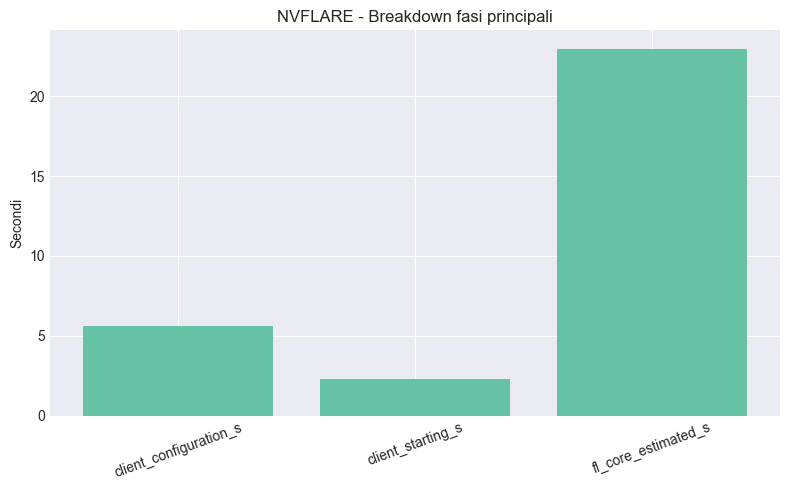

NVFLARE bottleneck share (% su tempo totale):
- client_configuration_s: 18.2%
- client_starting_s: 7.4%
- fl_core_estimated_s: 74.4%
- allreduce events osservati nel log: 1089


In [8]:
if not df_three.empty:
    order = df_three.sort_values("total_time_s")

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    sns.barplot(data=order, x="total_time_s", y="approach", ax=axes[0])
    axes[0].set_title("Tempo totale (3 approcci)")
    axes[0].set_xlabel("Secondi")
    axes[0].set_ylabel("")

    sns.barplot(data=order, x="avg_round_time_s", y="approach", ax=axes[1])
    axes[1].set_title("Tempo medio per round")
    axes[1].set_xlabel("Secondi")
    axes[1].set_ylabel("")

    plt.tight_layout()
    plt.show()

if "nvidia_flare" in set(df_three.get("approach", [])):
    row = df_three[df_three["approach"] == "nvidia_flare"].iloc[0]
    phase_parts = {
        "client_configuration_s": row.get("client_configuration_s", np.nan),
        "client_starting_s": row.get("client_starting_s", np.nan),
        "fl_core_estimated_s": row.get("fl_core_estimated_s", np.nan),
    }
    phase_parts = {k: v for k, v in phase_parts.items() if pd.notna(v) and v >= 0}

    if phase_parts:
        plt.figure(figsize=(8, 5))
        plt.bar(phase_parts.keys(), phase_parts.values())
        plt.xticks(rotation=20)
        plt.ylabel("Secondi")
        plt.title("NVFLARE - Breakdown fasi principali")
        plt.tight_layout()
        plt.show()

        total_nv = row["total_time_s"]
        print("NVFLARE bottleneck share (% su tempo totale):")
        for k, v in phase_parts.items():
            print(f"- {k}: {100 * v / total_nv:.1f}%")

        if pd.notna(row.get("allreduce_events", np.nan)):
            print(f"- allreduce events osservati nel log: {int(row['allreduce_events'])}")

### B2. Accuratezza: confronto 2-way e 3-way

Il notebook cerca MAE nei file risultati. Se mancante, usa il fallback manuale definito nella prima cella.

MAE disponibili:


,approach,mae,source
0,flower_bagging,12.23,manual_or_missing
1,flower_cyclic,11.38,manual_or_missing
2,nvidia_flare,NaN,manual_or_missing


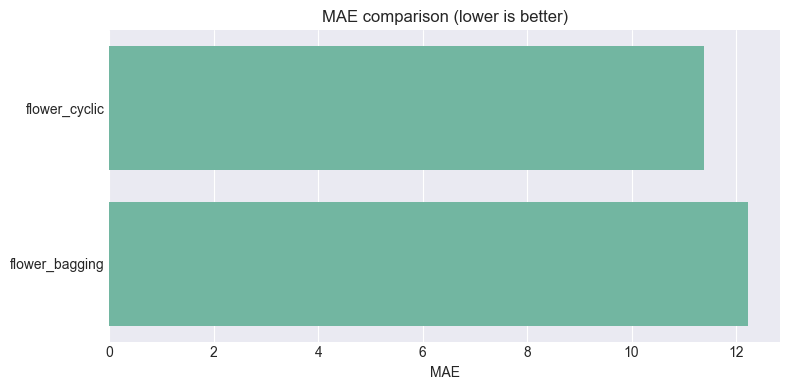

Migliore MAE attuale: flower_cyclic (11.380)


In [9]:
# Prova a leggere MAE dai csv risultati disponibili
csv_mae = {}
for csv_file in RESULTS_DIR.glob("*.csv"):
    try:
        df_tmp = pd.read_csv(csv_file)
        if "approach" in df_tmp.columns and "final_mae" in df_tmp.columns:
            for _, r in df_tmp.iterrows():
                if pd.notna(r.get("final_mae", np.nan)):
                    csv_mae[str(r["approach"])] = float(r["final_mae"])
    except Exception:
        pass

accuracy_records = []
for approach in ["flower_bagging", "flower_cyclic", "nvidia_flare"]:
    mae_value = csv_mae.get(approach, manual_mae.get(approach, np.nan))
    source = "csv" if approach in csv_mae else "manual_or_missing"
    accuracy_records.append({"approach": approach, "mae": mae_value, "source": source})

df_acc = pd.DataFrame(accuracy_records)
print("MAE disponibili:")
display(df_acc)

plot_acc = df_acc.dropna(subset=["mae"]) 
if not plot_acc.empty:
    plt.figure(figsize=(8, 4))
    order = plot_acc.sort_values("mae")
    sns.barplot(data=order, x="mae", y="approach")
    plt.title("MAE comparison (lower is better)")
    plt.xlabel("MAE")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

    print(f"Migliore MAE attuale: {order.iloc[0]['approach']} ({order.iloc[0]['mae']:.3f})")
else:
    print("Nessun MAE disponibile: aggiorna manual_mae o esporta metrica finale nei CSV.")

## Sintesi Operativa

- Per il confronto tempi: usare principalmente total_time_s, avg_round_time_s e breakdown NVFLARE da log.
- Per i bottleneck nodo-nodo: monitorare client_configuration_s, client_starting_s e numero eventi all_reduce.
- Per l'accuratezza: usare MAE dai CSV quando presente; altrimenti fallback manuale.

Prossimo miglioramento consigliato:
- salvare in modo uniforme final_mae e timing di fase per tutti e 3 gli approcci in JSON/CSV strutturati.

### DA fare

1. Confermare MAE di NVFLARE (se non ancora salvato in results CSV/JSON).
2. Rieseguire il notebook dall'inizio per avere grafici aggiornati.
3. Esportare figure principali:
   - tempi globali 2-way
   - tempi globali 3-way
   - breakdown NVFLARE
   - confronto MAE

## CHECK --- Parte C - Export strutturato metriche (schema unico)

Questa sezione crea un file CSV e JSON con schema uniforme per tutti gli approcci.

Output generati:
- `results/structured_metrics/latest_metrics_snapshot.csv`
- `results/structured_metrics/latest_metrics_snapshot.json`

Campi sempre presenti (quando disponibili):
- timing globali (`total_time_s`, `fl_time_s`, `avg_round_time_s`, `num_rounds`, `num_clients`)
- qualità (`final_mae`, `rmse`, `r2`)
- comunicazione (`allreduce_events`, `bytes_up_per_round`, `bytes_down_per_round`)
- breakdown fase (`client_configuration_s`, `client_starting_s`, `fl_core_estimated_s`)
- risorse (`cpu_percent_mean`, `memory_usage_mb_mean`, `memory_usage_mb_peak`)

I campi non disponibili restano `NaN`/vuoti ma con schema consistente per confronti futuri.

In [ ]:
from datetime import datetime

STRUCT_DIR = RESULTS_DIR / "structured_metrics"
STRUCT_DIR.mkdir(parents=True, exist_ok=True)


def extract_csv_metrics(results_dir: Path):
    """Legge metriche aggregate dai CSV disponibili in results/."""
    rows = []
    for csv_file in results_dir.glob("*.csv"):
        try:
            d = pd.read_csv(csv_file)
            if d.empty:
                continue
            r = d.iloc[-1].to_dict()
            rows.append({
                "source_file": csv_file.name,
                "approach": r.get("approach"),
                "final_mae": r.get("final_mae"),
                "cpu_percent_mean": r.get("cpu_percent_mean"),
                "memory_usage_mb_mean": r.get("memory_usage_mb_mean"),
                "memory_usage_mb_peak": r.get("memory_usage_mb_total"),
            })
        except Exception:
            continue
    if not rows:
        return pd.DataFrame(columns=[
            "source_file",
            "approach",
            "final_mae",
            "cpu_percent_mean",
            "memory_usage_mb_mean",
            "memory_usage_mb_peak",
        ])
    return pd.DataFrame(rows)


# Base timing dai JSON benchmark
def load_timing_row(approach_name: str, json_path: Path, default_clients=np.nan):
    payload = load_json_if_exists(json_path)
    if payload is None:
        return None
    total = float(payload.get("total_time", np.nan))
    fl_time = float(payload.get("fl_time", np.nan))
    return {
        "approach": approach_name,
        "framework": "flower" if "flower" in approach_name else "nvidia_flare",
        "total_time_s": total,
        "fl_time_s": fl_time,
        "avg_round_time_s": float(payload.get("avg_round_time", np.nan)),
        "num_rounds": payload.get("num_rounds", np.nan),
        "num_clients": payload.get("num_clients", default_clients),
        "setup_plus_overhead_s": max(total - fl_time, 0.0) if pd.notna(total) and pd.notna(fl_time) else np.nan,
        "round_time_list": payload.get("rounds", []),
        "tree_method": payload.get("tree_method", np.nan),
    }


rows = []
rows.append(load_timing_row("flower_bagging", BENCHMARKS_DIR / "flower_bagging" / "results" / "timing_metrics.json", default_clients=9))
rows.append(load_timing_row("flower_cyclic", BENCHMARKS_DIR / "flower_cyclic" / "results" / "timing_metrics.json", default_clients=9))
rows.append(load_timing_row("nvidia_flare", BENCHMARKS_DIR / "nvidia_flare" / "results" / "timing_metrics.json", default_clients=9))
rows = [r for r in rows if r is not None]

metrics_df = pd.DataFrame(rows)

# Enrichment NVFLARE da log
nv_log_path = BENCHMARKS_DIR / "nvidia_flare" / "run_nvflare.log"
if nv_log_path.exists() and not metrics_df.empty:
    raw = nv_log_path.read_text(errors="ignore")
    clean = re.sub(r"\x1b\[[0-9;]*m", "", raw)

    m_cfg = re.search(r"client configuration took ([0-9]+\.?[0-9]*) seconds", clean)
    m_start = re.search(r"client starting took ([0-9]+\.?[0-9]*) seconds", clean)
    allreduce = len(re.findall(r"Request seq op='allreduce'", clean))

    nv_ix = metrics_df[metrics_df["approach"] == "nvidia_flare"].index
    if len(nv_ix) > 0:
        i = nv_ix[0]
        metrics_df.loc[i, "client_configuration_s"] = float(m_cfg.group(1)) if m_cfg else np.nan
        metrics_df.loc[i, "client_starting_s"] = float(m_start.group(1)) if m_start else np.nan
        metrics_df.loc[i, "allreduce_events"] = allreduce

        fl_time = metrics_df.loc[i, "fl_time_s"]
        cfg = metrics_df.loc[i, "client_configuration_s"]
        sta = metrics_df.loc[i, "client_starting_s"]
        if pd.notna(fl_time):
            metrics_df.loc[i, "fl_core_estimated_s"] = fl_time - (cfg if pd.notna(cfg) else 0) - (sta if pd.notna(sta) else 0)

# Enrichment accuratezza/risorse da CSV
csv_df = extract_csv_metrics(RESULTS_DIR)
if not csv_df.empty:
    csv_best = csv_df.dropna(subset=["approach"]).groupby("approach", as_index=False).last()
    metrics_df = metrics_df.merge(
        csv_best[[
            "approach",
            "final_mae",
            "cpu_percent_mean",
            "memory_usage_mb_mean",
            "memory_usage_mb_peak",
            "source_file",
        ]],
        on="approach",
        how="left",
    )

# fallback MAE da notebook se manca nel CSV
if "final_mae" not in metrics_df.columns:
    metrics_df["final_mae"] = np.nan

for k, v in manual_mae.items():
    ix = metrics_df[metrics_df["approach"] == k].index
    if len(ix) > 0 and pd.isna(metrics_df.loc[ix[0], "final_mae"]):
        metrics_df.loc[ix[0], "final_mae"] = v

# Campi schema target (presenti anche se mancanti)
for col in [
    "rmse", "r2", "bytes_up_per_round", "bytes_down_per_round", "rpc_latency_p95_ms",
    "retry_error_rate", "straggler_wait_time_s", "round_time_p50_s", "round_time_p95_s",
]:
    if col not in metrics_df.columns:
        metrics_df[col] = np.nan

# serializza round list in formato testo JSON per CSV
metrics_df["round_time_list_json"] = metrics_df["round_time_list"].apply(lambda x: json.dumps(x) if isinstance(x, list) else json.dumps([]))
metrics_df["snapshot_ts"] = datetime.now().isoformat(timespec="seconds")

# riordino colonne principali
ordered_cols = [
    "snapshot_ts", "approach", "framework", "tree_method",
    "num_clients", "num_rounds",
    "total_time_s", "fl_time_s", "avg_round_time_s", "setup_plus_overhead_s",
    "client_configuration_s", "client_starting_s", "fl_core_estimated_s",
    "allreduce_events", "round_time_list_json", "round_time_p50_s", "round_time_p95_s",
    "final_mae", "rmse", "r2",
    "cpu_percent_mean", "memory_usage_mb_mean", "memory_usage_mb_peak",
    "bytes_up_per_round", "bytes_down_per_round", "rpc_latency_p95_ms",
    "straggler_wait_time_s", "retry_error_rate", "source_file",
]

for c in ordered_cols:
    if c not in metrics_df.columns:
        metrics_df[c] = np.nan

metrics_df = metrics_df[ordered_cols].sort_values("approach").reset_index(drop=True)

csv_out = STRUCT_DIR / "latest_metrics_snapshot.csv"
json_out = STRUCT_DIR / "latest_metrics_snapshot.json"
metrics_df.to_csv(csv_out, index=False)
metrics_df.to_json(json_out, orient="records", indent=2)

print("Export completato:")
print(f"- {csv_out}")
print(f"- {json_out}")
display(metrics_df)
